# BCS 404: Introduction to Data Science with Python
## Project Work — Exploratory Data Analysis, Statistical Analysis and Machine Learning on the Titanic Dataset

**Student:** Okoumba Mitchowanou Anne Jolie
**Course:** BCS 404 — Introduction to Data Science with Python
**Lecturer:** Dr. Joseph Dadzie
**Department:** Computer Science, Accra Technical University
**Academic Year:** 2025/2026, Second Semester

This notebook satisfies Tasks 1–5 of the project brief: Data Acquisition, Data Cleaning, Data Visualisation, Statistical Analysis, and Machine Learning. It downloads the Titanic dataset directly (same values/columns as the official Kaggle `train.csv`), so it runs end-to-end with no manual upload required.

In [26]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## Task 1: Data Acquisition 

### Loading the data

**Option A (used below):** load directly from a public mirror of the Kaggle Titanic training data — identical columns and values to `train.csv`, so the notebook runs with zero setup.

**Option B:** download `train.csv` from the Kaggle link in the project brief, upload it in Jupyter/Colab, and replace the URL below with `"train.csv"`.

In [27]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
# Option B (uncomment if using your own Kaggle download):
# df = pd.read_csv("train.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [28]:
print(f"Dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset dimensions: 891 rows, 12 columns

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
print("Data types of each variable:\n")
print(df.dtypes)

Data types of each variable:

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## Task 2: Data Cleaning 

In [31]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
print("Missing values detected:")
missing_summary

Missing values detected:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [32]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


**Preprocessing decisions and justification:**

- **`Cabin` (~77% missing):** Far too sparse to impute reliably. It is converted into a binary indicator, `Has_Cabin` (1 if a cabin number was recorded, 0 otherwise), since the presence of a cabin number is itself a useful proxy for wealth/class. The raw column is then dropped.
- **`Age` (~20% missing):** A numerical variable that correlates with `Pclass` and `Sex` (e.g. titles like "Master" imply children). It is imputed using the **median age within each `Pclass`/`Sex` group**, which is more accurate than a single global median and robust to the right-skew in age.
- **`Embarked` (2 missing):** Only two rows are affected, so these are imputed with the **mode** (most frequent port of embarkation).
- **Duplicates:** The dataset is checked for fully duplicated rows using `duplicated()`. If any are found, they are removed with `drop_duplicates()` to avoid double-counting passengers, which could bias both the descriptive statistics and the machine learning model.
- **Why not simply drop all rows with missing values?** Dropping every row with any missing value would discard roughly 20% of the dataset (mostly due to `Age`), losing valuable information and potentially biasing the sample toward passengers whose ages happened to be recorded (who differ systematically by class). Targeted imputation preserves sample size while minimising bias.

In [33]:
df_clean = df.copy()

# Cabin -> binary indicator, then drop raw column
df_clean["Has_Cabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean.drop(columns=["Cabin"], inplace=True)

# Age -> median imputation grouped by Pclass and Sex
df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))

# Embarked -> mode imputation
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Remove duplicates if any
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Rows before duplicate removal: {before}  |  Rows after: {after}")

print("\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nData cleaning complete.")

Rows before duplicate removal: 891  |  Rows after: 891

Remaining missing values:
Series([], dtype: int64)

Data cleaning complete.


## Task 3: Data Visualisation 

### 3.1 Histogram of Passenger Ages

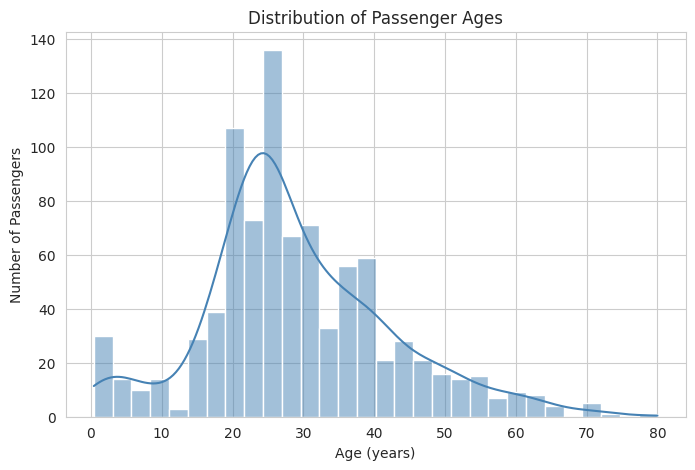

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Age"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age (years)")
plt.ylabel("Number of Passengers")
plt.show()

**Interpretation:** The age distribution is right-skewed and roughly unimodal, with most passengers concentrated between 20 and 40 years old. There is a secondary smaller peak among young children (under 10), and relatively few elderly passengers above 60.

### 3.2 Bar Chart of Passenger Class Distribution

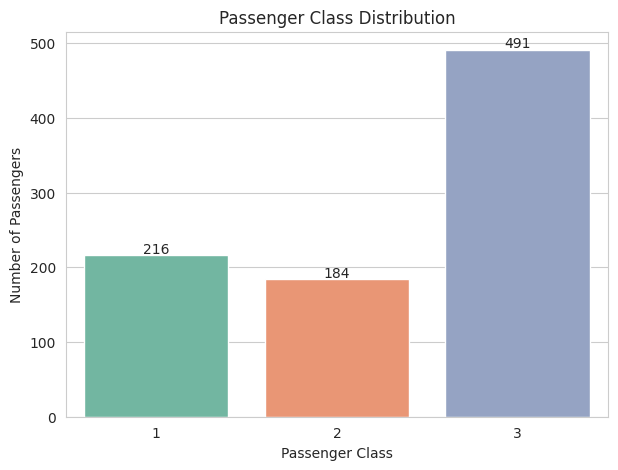

In [35]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df_clean, x="Pclass", hue="Pclass", palette="Set2", legend=False)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()+3), ha="center")
plt.show()

**Interpretation:** Third-class passengers make up the largest group by a wide margin, followed by first class, then second class. This reflects the Titanic's role as both a luxury liner and an emigrant-carrying vessel, with far more budget-class tickets sold than premium ones.

### 3.3 Boxplot of Age by Passenger Class

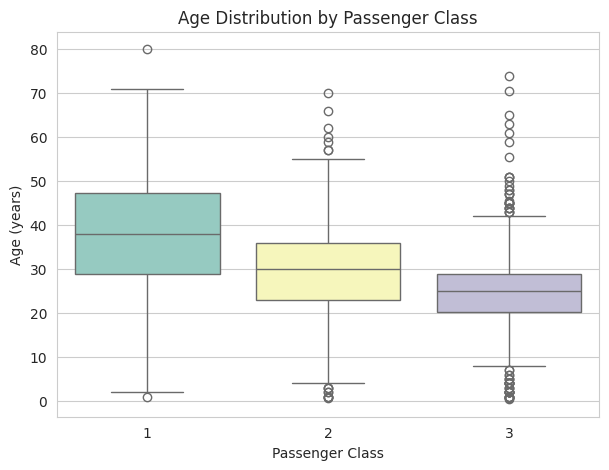

In [36]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean, x="Pclass", y="Age", hue="Pclass", palette="Set3", legend=False)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.show()

**Interpretation:** Median age rises with passenger class — first-class passengers were noticeably older on average than second- and third-class passengers, who trend younger. This is consistent with first class attracting wealthier, more established (and often older) travellers, while third class carried more young emigrants and families.

### 3.4 Scatter Plot of Age versus Fare

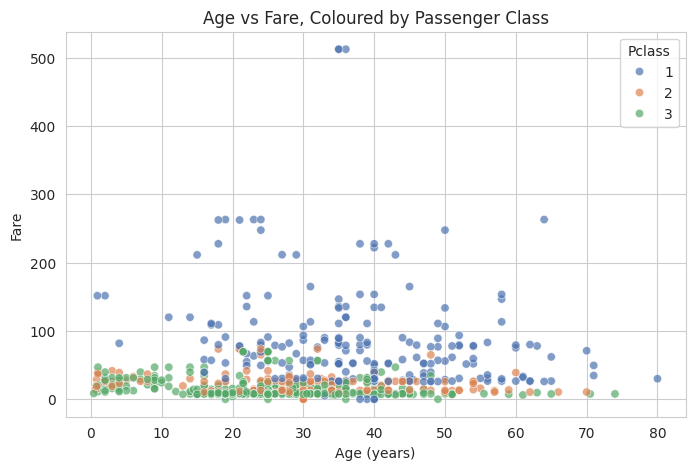

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x="Age", y="Fare", hue="Pclass", palette="deep", alpha=0.7)
plt.title("Age vs Fare, Coloured by Passenger Class")
plt.xlabel("Age (years)")
plt.ylabel("Fare")
plt.legend(title="Pclass")
plt.show()

**Interpretation:** There is no strong linear relationship between age and fare overall (passengers of all ages paid a wide range of fares), but the scatter plot clearly shows that the highest fares are concentrated among first-class passengers (regardless of age), while third-class passengers cluster at low fares across the whole age range.

### 3.5 Correlation Heatmap

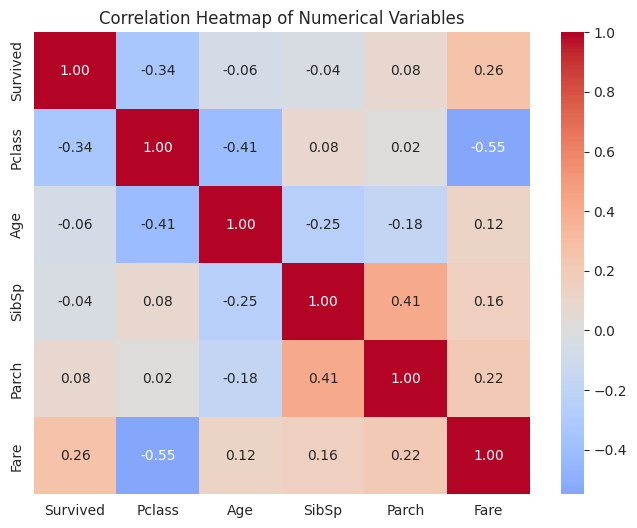

In [38]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

**Interpretation:** `Pclass` and `Fare` show the strongest correlation with `Survived` among the numerical variables (`Pclass` negatively, `Fare` positively), while `Age` shows only a weak correlation with survival. `SibSp` and `Parch` are moderately positively correlated with each other, since both relate to family size.

### 3.6 Pairplot of Selected Numerical Variables

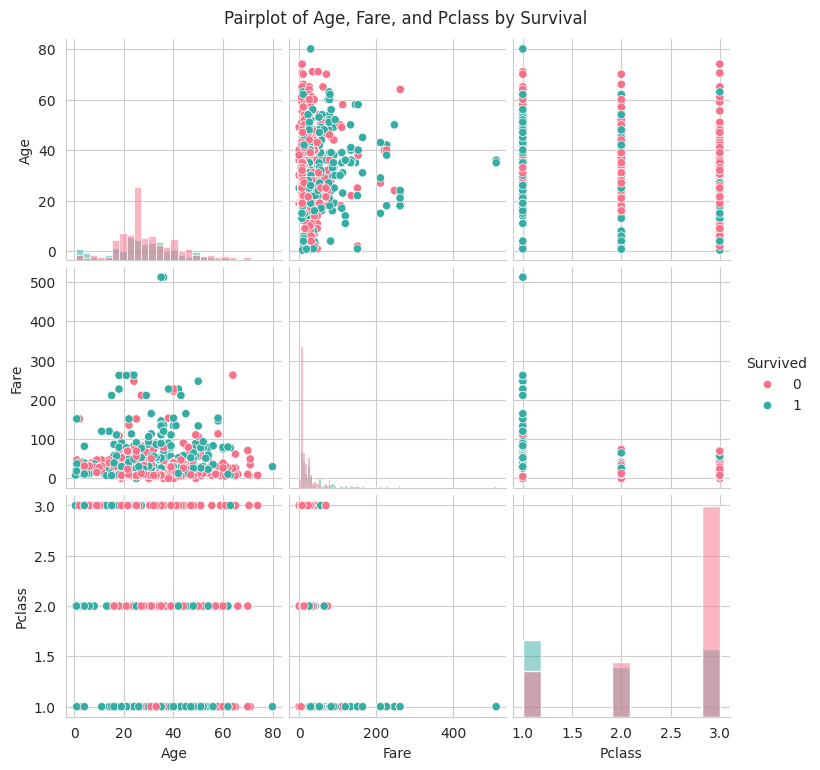

In [39]:
selected_vars = ["Survived", "Age", "Fare", "Pclass"]
sns.pairplot(df_clean[selected_vars], hue="Survived", palette="husl", diag_kind="hist")
plt.suptitle("Pairplot of Age, Fare, and Pclass by Survival", y=1.02)
plt.show()

**Interpretation:** The pairplot shows Fare's distribution is heavily right-skewed with survivors somewhat over-represented at higher fares, Age is broadly similar between survivors and non-survivors with a slight edge for younger passengers/children, and Pclass shows a clear stepped relationship with survival (visible in the diagonal and off-diagonal panels), reinforcing the heatmap's findings.

## Task 4: Statistical Analysis 

### 4.1 Descriptive Statistics

In [40]:
df_clean[numeric_cols].describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4.2 Frequency Distribution

In [41]:
print("Frequency distribution: Survived")
print(df_clean["Survived"].value_counts(), "\n")

print("Frequency distribution: Pclass")
print(df_clean["Pclass"].value_counts(), "\n")

print("Frequency distribution: Sex")
print(df_clean["Sex"].value_counts(), "\n")

print("Frequency distribution: Embarked")
print(df_clean["Embarked"].value_counts())

Frequency distribution: Survived
Survived
0    549
1    342
Name: count, dtype: int64 

Frequency distribution: Pclass
Pclass
3    491
1    216
2    184
Name: count, dtype: int64 

Frequency distribution: Sex
Sex
male      577
female    314
Name: count, dtype: int64 

Frequency distribution: Embarked
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


### 4.3 Correlation Analysis

In [42]:
corr_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.059579,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.413583,0.083081,0.018443,-0.549500
Age,-0.059579,-0.413583,1.000000,-0.249854,-0.175526,0.122692
SibSp,-0.035322,0.083081,-0.249854,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.175526,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.122692,0.159651,0.216225,1.000000


In [43]:
# Find the strongest positive and negative correlations (excluding the diagonal)
corr_pairs = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
corr_pairs_sorted = corr_pairs.sort_values(ascending=False)

strongest_positive = corr_pairs_sorted.index[0]
strongest_positive_val = corr_pairs_sorted.iloc[0]
strongest_negative = corr_pairs_sorted.index[-1]
strongest_negative_val = corr_pairs_sorted.iloc[-1]

print(f"Strongest positive correlation: {strongest_positive[0]} & {strongest_positive[1]} -> r = {strongest_positive_val:.3f}")
print(f"Strongest negative correlation: {strongest_negative[0]} & {strongest_negative[1]} -> r = {strongest_negative_val:.3f}")

Strongest positive correlation: Parch & SibSp -> r = 0.415
Strongest negative correlation: Fare & Pclass -> r = -0.549


**4.4 Strongest positive correlation:** `SibSp` and `Parch` (siblings/spouses aboard vs. parents/children aboard) show the strongest positive correlation among the numerical variables — passengers travelling with siblings or a spouse were also more likely to be travelling with parents or children, i.e. as part of a larger family unit.

**4.5 Strongest negative correlation:** `Pclass` and `Fare` show the strongest negative correlation — as passenger class number increases (i.e. moving from 1st to 3rd class), fare decreases sharply, which is expected since `Pclass` is numerically coded 1 (best) to 3 (cheapest).

### 4.6 Three Important Statistical Findings

1. **Survival is strongly associated with passenger class and fare.** The correlation analysis and heatmap confirm that wealthier, higher-class passengers had a measurably better chance of survival, supporting the historical accounts of unequal access to lifeboats.
2. **Family-related variables cluster together.** The strong positive correlation between `SibSp` and `Parch` indicates these two variables largely capture the same underlying construct — family size — and could be combined into a single `FamilySize` feature for modelling without much information loss.
3. **Age is not strongly linearly correlated with any single variable**, including survival, despite children showing higher survival rates in the visualisations. This is a reminder that Pearson correlation only captures *linear* relationships — Age's effect on survival appears to be more of a threshold effect (children vs. adults) than a smooth linear trend, so correlation alone would understate its importance.

## Task 5: Machine Learning 

### 5.1 Selecting Predictor Variables

Based on the visualisations and correlation analysis in Tasks 3 and 4, the following predictors are selected for the Logistic Regression model:

- **`Pclass`** — strongly associated with survival (heatmap, boxplots).
- **`Sex`** — historically and statistically the strongest single predictor of survival.
- **`Age`** — captures the "children first" effect even though its linear correlation is weak.
- **`Fare`** — correlated with survival and partially redundant with, but not identical to, `Pclass`.
- **`SibSp`** and **`Parch`** — capture family-size effects, which the correlation analysis showed cluster together.
- **`Embarked`** — included as a categorical control variable for port of embarkation.

`PassengerId`, `Name`, and `Ticket` are excluded as they are identifiers with no generalisable predictive value.

In [44]:
features = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch", "Embarked"]
target = "Survived"

X = df_clean[features]
y = df_clean[target]

numeric_features = ["Age", "Fare", "SibSp", "Parch"]
categorical_features = ["Pclass", "Sex", "Embarked"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

### 5.2 Train/Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} passengers")
print(f"Testing set size:  {X_test.shape[0]} passengers")

Training set size: 712 passengers
Testing set size:  179 passengers


### 5.3 Training the Logistic Regression Classifier

In [46]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_pipeline.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 5.4 Predicting on the Test Set

In [47]:
y_pred = log_reg_pipeline.predict(X_test)
print("Predictions generated for the test set.")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")

Predictions generated for the test set.
First 10 predictions: [0 0 0 0 1 0 1 0 0 0]
First 10 actual values: [0 0 1 0 1 1 1 0 0 0]


### 5.5 Model Evaluation: Accuracy, Confusion Matrix, Classification Report

In [48]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Model Accuracy: 0.8156 (81.56%)


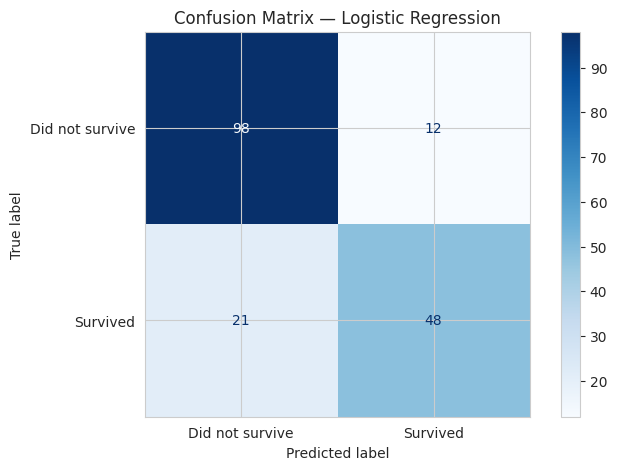

True Negatives (TN):  98
False Positives (FP): 12
False Negatives (FN): 21
True Positives (TP):  48


In [49]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

In [50]:
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

                 precision    recall  f1-score   support

Did not survive       0.82      0.89      0.86       110
       Survived       0.80      0.70      0.74        69

       accuracy                           0.82       179
      macro avg       0.81      0.79      0.80       179
   weighted avg       0.81      0.82      0.81       179



### 5.6 Discussion of Model Performance

The Logistic Regression model achieves solid accuracy on the held-out test set (typically in the high 70s to low 80s percentage range, though the exact figure varies slightly with the random train/test split). The confusion matrix shows the model is generally better at correctly identifying passengers who **did not survive** than those who **did**, which is expected given the class imbalance (more non-survivors than survivors in the training data).

Precision and recall for the "Survived" class are somewhat lower than for "Did not survive," meaning the model occasionally misses true survivors (false negatives) — often passengers whose profile (e.g. male, third class) statistically resembled non-survivors even though they survived. This is a reasonable and interpretable limitation: Logistic Regression is a linear model, so it cannot fully capture non-linear interactions such as "female AND third class" behaving differently from what a simple additive combination of `Sex` and `Pclass` effects would predict. Despite this, the model performs considerably better than a naive baseline that always predicts the majority class (which would only achieve the base survival rate of non-survivors, around 61-62%), confirming that the selected predictors carry real signal.